In [1]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
print(torch.__version__)

2.11.0+cu128


In [15]:
# ============================================================
# Configuration
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = 5
IMAGE_SIZE = 224
BATCH_SIZE = 32

TEST_DIR = "../data/raw/Lung_Disease_Dataset/test"

BASELINE_MODEL_PATH = "../models/Baseline/baseline_cnn_best.pth"
EFFICIENTNET_MODEL_PATH = "../models/Transfer_1/efficientnet_head_best.pth"

print("Device :", DEVICE)
print("Test Directory :", TEST_DIR)
print("Baseline Model :", BASELINE_MODEL_PATH)
print("EfficientNet Model :", EFFICIENTNET_MODEL_PATH)

Device : cuda
Test Directory : ../data/raw/Lung_Disease_Dataset/test
Baseline Model : ../models/Baseline/baseline_cnn_best.pth
EfficientNet Model : ../models/Transfer_1/efficientnet_head_best.pth


In [9]:
# ============================================================
# Test Transform
# ============================================================

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# Test Dataset
# ============================================================

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

CLASS_NAMES = test_dataset.classes

print("Classes:")
print(CLASS_NAMES)

print("\nNumber of Test Images:", len(test_dataset))

print("\nClass to Index Mapping:")
print(test_dataset.class_to_idx)

Classes:
['Bacterial Pneumonia', 'Corona Virus Disease', 'Normal', 'Tuberculosis', 'Viral Pneumonia']

Number of Test Images: 2025

Class to Index Mapping:
{'Bacterial Pneumonia': 0, 'Corona Virus Disease': 1, 'Normal': 2, 'Tuberculosis': 3, 'Viral Pneumonia': 4}


In [10]:
import torch
import torch.nn as nn

class BaselineCNN(nn.Module):

    def __init__(self, num_classes=5):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.15),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.15),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.15),
            nn.MaxPool2d(2)
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),

            nn.Linear(256, num_classes)
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():

            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")

            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):

        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)

        return x

In [11]:
# ============================================================
# Load Baseline CNN
# ============================================================

baseline = BaselineCNN(num_classes=NUM_CLASSES)

baseline.load_state_dict(
    torch.load(
        BASELINE_MODEL_PATH,
        map_location=DEVICE
    )
)

baseline = baseline.to(DEVICE)
baseline.eval()

print("✅ Baseline CNN loaded successfully!")

✅ Baseline CNN loaded successfully!


In [17]:
checkpoint = torch.load(
    EFFICIENTNET_MODEL_PATH,
    map_location=DEVICE
)

print(type(checkpoint))
print(checkpoint.keys())

<class 'dict'>
dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'accuracy', 'precision', 'recall', 'f1', 'score'])


In [18]:
# ============================================================
# Load EfficientNet-B0
# ============================================================

from torchvision import models
import torch.nn as nn

# Create EfficientNet-B0
efficientnet = models.efficientnet_b0(weights=None)

# Number of features
in_features = efficientnet.classifier[1].in_features

# Replace classifier
efficientnet.classifier = nn.Sequential(

    nn.Dropout(0.5),

    nn.Linear(in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(inplace=True),

    nn.Dropout(0.30),

    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(inplace=True),

    nn.Dropout(0.20),

    nn.Linear(256, NUM_CLASSES)

)

# ============================================================
# Load Checkpoint
# ============================================================

checkpoint = torch.load(
    EFFICIENTNET_MODEL_PATH,
    map_location=DEVICE
)

efficientnet.load_state_dict(
    checkpoint["model_state_dict"]
)

efficientnet = efficientnet.to(DEVICE)
efficientnet.eval()

print("✅ EfficientNet loaded successfully!")

✅ EfficientNet loaded successfully!


In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns


def evaluate_model(model, model_name):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro")
    recall = recall_score(y_true, y_pred, average="macro")
    f1 = f1_score(y_true, y_pred, average="macro")

    print("\n" + "="*70)
    print(model_name)
    print("="*70)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report\n")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=CLASS_NAMES,
            digits=4
        )
    )

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(model_name)

    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }


Baseline CNN
Accuracy : 0.8425
Precision: 0.8412
Recall   : 0.8419
F1 Score : 0.8397

Classification Report

                      precision    recall  f1-score   support

 Bacterial Pneumonia     0.7011    0.7742    0.7358       403
Corona Virus Disease     0.9738    0.9115    0.9416       407
              Normal     0.8696    0.9406    0.9037       404
        Tuberculosis     0.9458    0.9828    0.9639       408
     Viral Pneumonia     0.7160    0.6005    0.6532       403

            accuracy                         0.8425      2025
           macro avg     0.8412    0.8419    0.8397      2025
        weighted avg     0.8418    0.8425    0.8402      2025



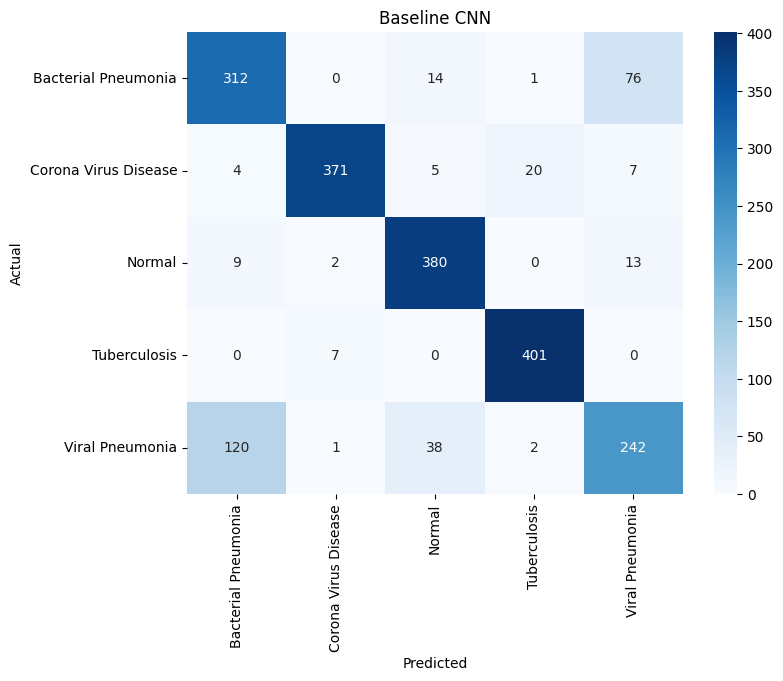

In [20]:
baseline_results = evaluate_model(
    baseline,
    "Baseline CNN"
)


EfficientNet-B0
Accuracy : 0.8469
Precision: 0.8447
Recall   : 0.8463
F1 Score : 0.8419

Classification Report

                      precision    recall  f1-score   support

 Bacterial Pneumonia     0.7813    0.6650    0.7185       403
Corona Virus Disease     0.9304    0.9853    0.9570       407
              Normal     0.7936    0.9802    0.8771       404
        Tuberculosis     0.9821    0.9436    0.9625       408
     Viral Pneumonia     0.7361    0.6576    0.6946       403

            accuracy                         0.8469      2025
           macro avg     0.8447    0.8463    0.8419      2025
        weighted avg     0.8452    0.8469    0.8425      2025



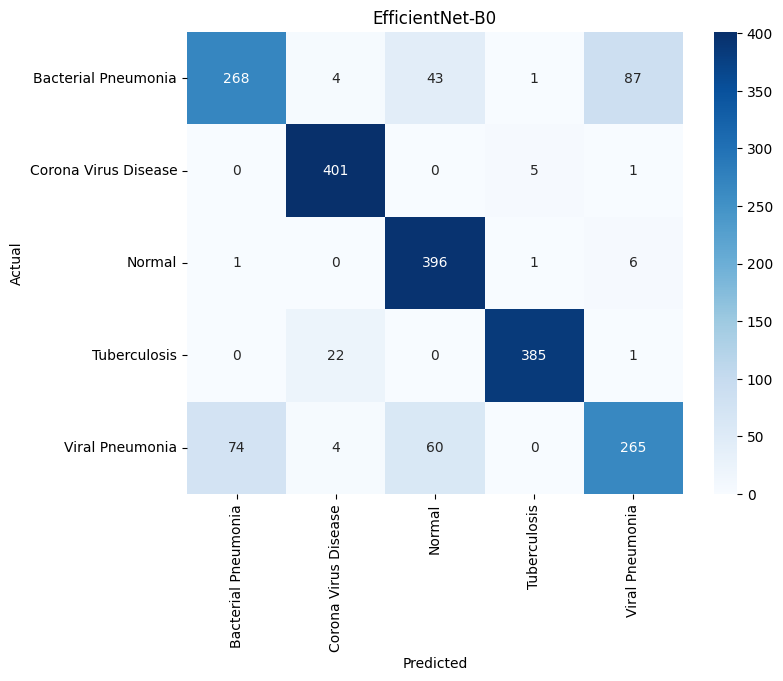

In [21]:
efficientnet_results = evaluate_model(
    efficientnet,
    "EfficientNet-B0"
)

In [22]:
comparison = pd.DataFrame([
    baseline_results,
    efficientnet_results
])

comparison = comparison.sort_values(
    by=["Recall", "F1", "Accuracy"],
    ascending=False
)

comparison

,Model,Accuracy,Precision,Recall,F1
1,EfficientNet-B0,0.846914,0.844715,0.846333,0.841948
0,Baseline CNN,0.842469,0.841235,0.841935,0.839655


In [23]:
winner = comparison.iloc[0]

print("=" * 60)
print("🏆 FINAL MODEL SELECTION")
print("=" * 60)

print(f"Selected Model : {winner['Model']}")
print(f"Accuracy       : {winner['Accuracy']:.4f}")
print(f"Precision      : {winner['Precision']:.4f}")
print(f"Recall         : {winner['Recall']:.4f}")
print(f"F1 Score       : {winner['F1']:.4f}")

🏆 FINAL MODEL SELECTION
Selected Model : EfficientNet-B0
Accuracy       : 0.8469
Precision      : 0.8447
Recall         : 0.8463
F1 Score       : 0.8419


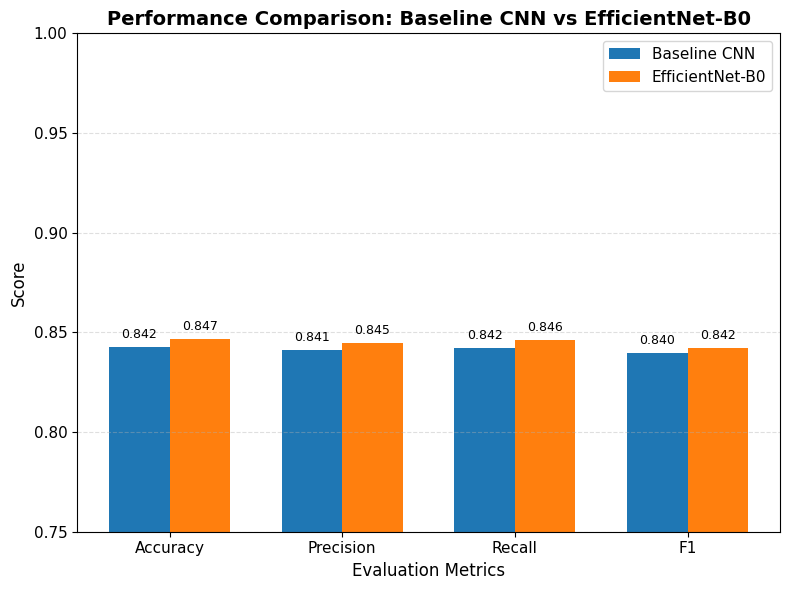

✅ Figure saved at: ../results\model_comparison_metrics.png


In [28]:
import os
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Create Results Directory
# ============================================================

RESULTS_DIR = "../results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# ============================================================
# Metrics
# ============================================================

metrics = ["Accuracy", "Precision", "Recall", "F1"]

baseline_scores = [
    baseline_results["Accuracy"],
    baseline_results["Precision"],
    baseline_results["Recall"],
    baseline_results["F1"]
]

efficientnet_scores = [
    efficientnet_results["Accuracy"],
    efficientnet_results["Precision"],
    efficientnet_results["Recall"],
    efficientnet_results["F1"]
]

# ============================================================
# Plot
# ============================================================

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 6))

bars1 = plt.bar(
    x - width/2,
    baseline_scores,
    width,
    label="Baseline CNN"
)

bars2 = plt.bar(
    x + width/2,
    efficientnet_scores,
    width,
    label="EfficientNet-B0"
)

plt.xticks(x, metrics, fontsize=11)
plt.yticks(fontsize=11)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Evaluation Metrics", fontsize=12)
plt.title("Performance Comparison: Baseline CNN vs EfficientNet-B0",
          fontsize=14,
          fontweight="bold")

plt.ylim(0.75, 1.0)

# ============================================================
# Add Values on Bars
# ============================================================

for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.legend(fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

# ============================================================
# Save Figure BEFORE Showing
# ============================================================

save_path = os.path.join(
    RESULTS_DIR,
    "model_comparison_metrics.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"✅ Figure saved at: {save_path}")

<Figure size 640x480 with 0 Axes>